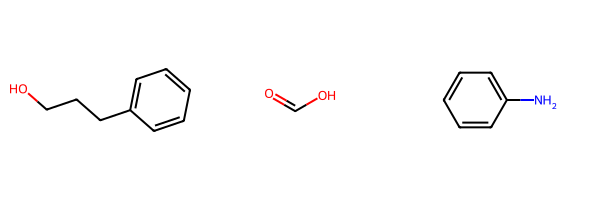

[05:38:32] Can't kekulize mol.  Unkekulized atoms: 1 2 7 8 9
[05:38:32] Can't kekulize mol.  Unkekulized atoms: 1 2 7 8 9
[05:38:32] Can't kekulize mol.  Unkekulized atoms: 1 2 7 8 9
[05:38:32] Can't kekulize mol.  Unkekulized atoms: 1 2 7 8 9
[05:38:32] Can't kekulize mol.  Unkekulized atoms: 1 2 7 8 9
[05:38:32] Can't kekulize mol.  Unkekulized atoms: 1 2 7 8 9
[05:38:32] Can't kekulize mol.  Unkekulized atoms: 1 2 7 8 9


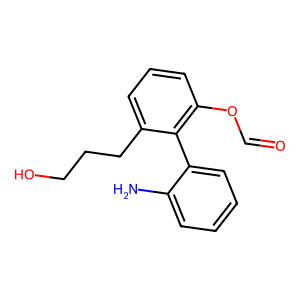

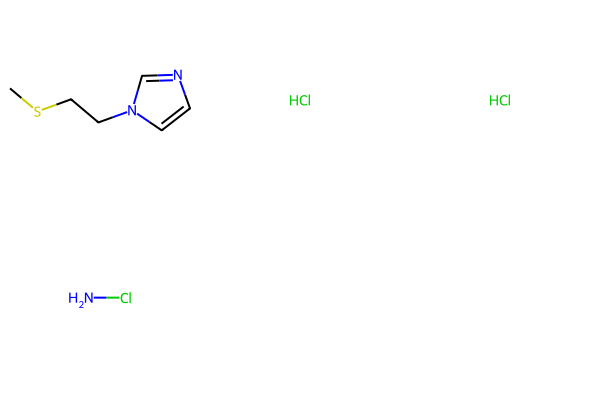

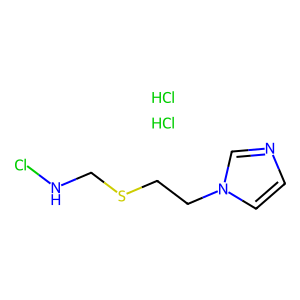

In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.rdchem import BondType
from rdkit.Chem import Draw
import itertools
from IPython.display import Image, display


# 결합 가능한 원자쌍 필터 기준 정의
ALLOWED_ATOM_PAIRS = {
    ('C', 'C'), ('C', 'N'), ('C', 'O'),
    ('N', 'N'), ('N', 'O'),
    ('O', 'O'),
}

def get_reactive_atoms(mol):
    """결합 가능한 원자 후보 추출"""
    reactive_atoms = []
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        if symbol not in ['C', 'N', 'O']:
            continue
        # valence 여유가 있거나, H를 하나 가지고 있으면 결합 후보로 간주
        num_explicit_h = sum(1 for nbr in atom.GetNeighbors() if nbr.GetSymbol() == 'H')
        if atom.GetDegree() < atom.GetTotalValence() or num_explicit_h > 0:
            reactive_atoms.append((atom.GetIdx(), atom.GetSymbol()))
    return reactive_atoms

def remove_hydrogens_for_bonding(mol, idx):
    """결합을 위해 해당 원자에 붙은 수소 제거"""
    rw_mol = Chem.RWMol(mol)
    atom = rw_mol.GetAtomWithIdx(idx)
    for nbr in atom.GetNeighbors():
        if nbr.GetSymbol() == 'H':
            rw_mol.RemoveAtom(nbr.GetIdx())
            break
    return rw_mol

def try_combine_mols(mol1, mol2, idx1, idx2):
    """두 원자 인덱스를 결합하여 새로운 molecule 생성"""
    rw_mol1 = Chem.RWMol(mol1)
    rw_mol2 = Chem.RWMol(mol2)

    # 각 원자의 수소 제거 (있는 경우)
    rw_mol1 = remove_hydrogens_for_bonding(rw_mol1, idx1)
    rw_mol2 = remove_hydrogens_for_bonding(rw_mol2, idx2)

    # 병합
    combo = Chem.CombineMols(rw_mol1, rw_mol2)
    editable_combo = Chem.EditableMol(combo)

    # 두 원자의 인덱스는 mol1의 idx1, mol2의 idx2 + mol1의 원자 수
    offset = mol1.GetNumAtoms()
    try:
        editable_combo.AddBond(idx1, idx2 + offset, BondType.SINGLE)
        new_mol = editable_combo.GetMol()
        Chem.SanitizeMol(new_mol)
        return new_mol
    except Exception:
        return None

def generate_all_possible_combinations(mol1, mol2):
    atoms1 = get_reactive_atoms(mol1)
    atoms2 = get_reactive_atoms(mol2)
    # valid_molecules = []  # if you want to keep all valid molecules

    for (idx1, sym1), (idx2, sym2) in itertools.product(atoms1, atoms2):
        if (sym1, sym2) in ALLOWED_ATOM_PAIRS or (sym2, sym1) in ALLOWED_ATOM_PAIRS:
            new_mol = try_combine_mols(mol1, mol2, idx1, idx2)
            if new_mol:
                # valid_molecules.append(new_mol)
                return new_mol
    return None

def get_combine_mole(mol_list):
    combine_mol = mol_list[0]
    for i in range(1, len(mol_list)):
        candi_combine_mol = generate_all_possible_combinations(combine_mol, mol_list[i])
        if candi_combine_mol:
            combine_mol = candi_combine_mol
        else:
            combine_mol = Chem.CombineMols(combine_mol, mol_list[i])
    return combine_mol

def split_smiles_to_mols(mixture_smiles):
    """혼합된 SMILES (예: Cl.Cl.CN) → Mol 객체 리스트로 분리"""
    mol = Chem.MolFromSmiles(mixture_smiles)
    frags = Chem.GetMolFrags(mol, asMols=True, sanitizeFrags=True)
    return list(frags)


if __name__=="__main__":
    smiles_list = [
        'c1cc(CCCO)ccc1',
        'OC=O',
        'c1ccccc1N'
    ]
    # merge smiles_list
    mol_list = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]
    display(Draw.MolsToGridImage(mol_list))
    combine_mol = get_combine_mole(mol_list)
    img = Draw.MolToImage(combine_mol)
    img.show()

    # merge mixture smiles if some substructures are removed by rejection
    mol_list = split_smiles_to_mols('CSCCn1ccnc1.Cl.Cl.NCl')
    display(Draw.MolsToGridImage(mol_list))
    combine_mol = get_combine_mole(mol_list)
    img = Draw.MolToImage(combine_mol)
    img.show()